# Введение
## Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
## Постановка задачи
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 

3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально), нормализовать признаки.

4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

5. Построить регрессионные модели (линейная и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

7. Повторить шаг 5 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

# Описание датасета
[Concrete Compressive Strength Dataset](https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set)
Этот многомерный датасет содержит информацию о составе бетонных смесей и их возрасте для прогнозирования ключевого показателя качества — прочности на сжатие. Набор данных включает 1030 наблюдений с 8 признаками (количество цемента, шлака, золы-уноса, воды, пластификатора, крупного и мелкого заполнителя, а также возраст образца) и одной целевой переменной. Данные представлены в сыром виде и не содержат пропусков, что делает датасет готовым к использованию в задачах регрессионного анализа и машинного обучения.


|Название переменной|Тип данных|Единица измерения|Описание|Тип переменной|
|-|-|-|-|-|
|Cement|Числовая переменная|кг в м³ смеси|Количество цемента в смеси (Компонент 1)|Независимая|
|Blast Furnace Slag|Числовая переменная|кг в м³ смеси|Количество гранулированного доменного шлака (Компонент 2)|Независимая|
|Fly Ash|Числовая переменная|кг в м³ смеси|Количество золы-уноса (Компонент 3)|Независимая|
|Water|Числовая переменная|кг в м³ смеси|Количество воды (Компонент 4)|Независимая|
|Superplasticizer|Числовая переменная|кг в м³ смеси|Количество суперпластификатора (Компонент 5)|Независимая|
|Coarse Aggregate|Числовая переменная|кг в м³ смеси|Количество крупного заполнителя (Компонент 6)|Независимая|
|Fine Aggregate|Числовая переменная|кг в м³ смеси|Количество мелкого заполнителя (Компонент 7)|Независимая|
|Age|Числовая переменная|День (1-365)|Возраст бетона на момент испытания|Независимая|
|Concrete compressive strength|Числовая переменная|Мегапаскали (МПа)|Прочность бетона на сжатие|Зависимая|


In [292]:
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy
import kagglehub
import math
import scipy.stats as stats

# Загрузка данных
file_path = "concrete_data.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "elikplim/concrete-compressive-strength-data-set",
  file_path,
)

display(df.head())

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Графики распределения признаков
Расчет количества интервалов по формуле Стержиса

In [293]:
# Функция для построения гистограммы распределения признаков и вывода стастистики
def print_stats(dataframe, feature_name, k):
    plt.hist(dataframe[feature_name], bins=k, edgecolor='black')
    plt.title(f'Распределение признака {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Частота')

    shapiro_test = stats.shapiro(dataframe[feature_name])
    dagostino_test = stats.normaltest(dataframe[feature_name])
    ks_test = stats.kstest(
        dataframe[feature_name],
        'norm',
        args=(dataframe[feature_name].mean(), dataframe[feature_name].std())
    )

    def interpret_pvalue(p):
        if p > 0.05:
            return "Нормальное"
        elif p > 0.01:
            return "Близко к нормальному"
        else:
            return "Далеко от нормального"
    

    # Дескриптивный анализ
    print (
        f"Статистика для признака {feature_name}:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Среднее:                  | {dataframe[feature_name].mean()}\n"
        f"Медиана:                  | {dataframe[feature_name].median()}\n"
        f"Мода:                     | {dataframe[feature_name].mode()[0]}\n"
        f"Минимум:                  | {dataframe[feature_name].min()}\n"
        f"Максимум:                 | {dataframe[feature_name].max()}\n"
        f"Размах:                   | {dataframe[feature_name].max() - dataframe[feature_name].min()}\n"
        f"Стандартное отклонение:   | {dataframe[feature_name].std()}\n"
        f"Дисперсия:                | {dataframe[feature_name].var()}\n"
        f"Асимметрия:               | {dataframe[feature_name].skew()}\n"
        f"Эксцесс:                  | {dataframe[feature_name].kurtosis()}\n"
        f"Квантили (25%, 50%, 75%): | {dataframe[feature_name].quantile([0.25, 0.5, 0.75]).to_dict()}\n"
        f"Оценка нормальности распредления:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Шапиро-Уилк:              | p={shapiro_test.pvalue:.3e} → {interpret_pvalue(shapiro_test.pvalue)}\n"
        f"Д'Агостино-Пиросона:      | p={dagostino_test.pvalue:.3e} → {interpret_pvalue(dagostino_test.pvalue)}\n"
        f"Колмагорова-Смирнова      | p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}\n"
    )



n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))
print(f"Количество записей: {n}")
print(f"Количество интервалов по формуле Стержиса: {k}")

Количество записей: 1030
Количество интервалов по формуле Стержиса: 12


### Анализ параметра Cement (Количество цемента в смеси)

Статистика для признака cement:
--------------------------|-------------------------------------------
Среднее:                  | 281.16786407766995
Медиана:                  | 272.9
Мода:                     | 362.6
Минимум:                  | 102.0
Максимум:                 | 540.0
Размах:                   | 438.0
Стандартное отклонение:   | 104.50636449481532
Дисперсия:                | 10921.580219923197
Асимметрия:               | 0.509481178871773
Эксцесс:                  | -0.5206522844987744
Квантили (25%, 50%, 75%): | {0.25: 192.375, 0.5: 272.9, 0.75: 350.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.082e-16 → Далеко от нормального
Д'Агостино-Пиросона:      | p=3.882e-14 → Далеко от нормального
Колмагорова-Смирнова      | p=5.625e-06 → Далеко от нормального



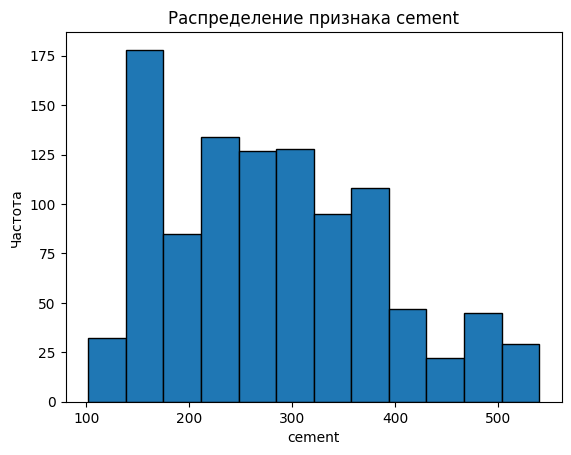

In [294]:
print_stats(df, 'cement', k)

Расперделение является плосковершинным и имеет правосторонную ассиметрию. Между медианой и средней имеется разница, а так же большая разница с модой.  
На основе результатов тестов и анализа распределение не явялется нормальным.


### Анализ параметра Blast Furnace Slag (Количество гранулированного доменного шлака)

Статистика для признака blast_furnace_slag:
--------------------------|-------------------------------------------
Среднее:                  | 73.89582524271846
Медиана:                  | 22.0
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 359.4
Размах:                   | 359.4
Стандартное отклонение:   | 86.27934174810584
Дисперсия:                | 7444.124812486438
Асимметрия:               | 0.8007168956061772
Эксцесс:                  | -0.5081754788835449
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 22.0, 0.75: 142.95}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=5.796e-33 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.314e-24 → Далеко от нормального
Колмагорова-Смирнова      | p=1.368e-62 → Далеко от нормального



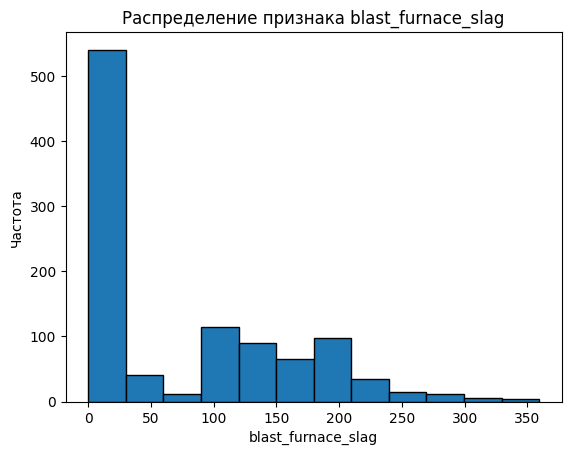

In [295]:
print_stats(df, 'blast_furnace_slag', k)

Расперделение является островершинным и имеет правосторонную ассиметрию. Между медианой, средним и иодой имеется значительная разница.  
На основе результатов тестов и анализа распределение не явялется нормальным.

### Анализ параметра Fly Ash (Количество золы-уноса)

Статистика для признака fly_ash:
--------------------------|-------------------------------------------
Среднее:                  | 54.18834951456311
Медиана:                  | 0.0
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 200.1
Размах:                   | 200.1
Стандартное отклонение:   | 63.99700415268765
Дисперсия:                | 4095.6165405191205
Асимметрия:               | 0.5373539058066844
Эксцесс:                  | -1.3287464346799722
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 0.0, 0.75: 118.3}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=4.135e-36 → Далеко от нормального
Д'Агостино-Пиросона:      | p=0.000e+00 → Далеко от нормального
Колмагорова-Смирнова      | p=6.355e-114 → Далеко от нормального



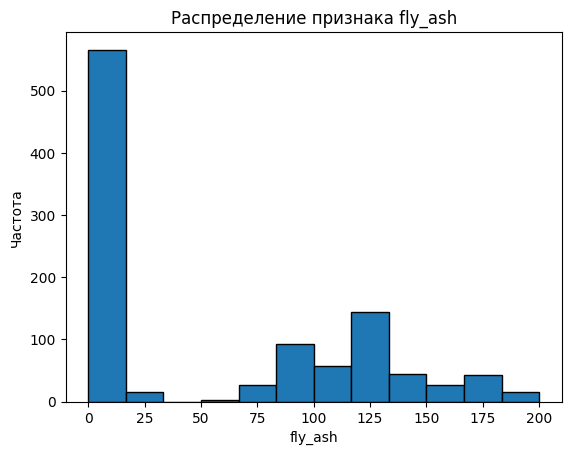

In [296]:
print_stats(df, 'fly_ash', k)

Расперделение является островершинным и имеет правосторонную ассиметрию. Между медианой, средним и иодой имеется значительная разница.  
На основе результатов тестов и анализа распределение не явялется нормальным.

### Анализ параметра Water (Количество воды)

Статистика для признака water:
--------------------------|-------------------------------------------
Среднее:                  | 181.56728155339806
Медиана:                  | 185.0
Мода:                     | 192.0
Минимум:                  | 121.8
Максимум:                 | 247.0
Размах:                   | 125.2
Стандартное отклонение:   | 21.35421856503247
Дисперсия:                | 456.00265052317735
Асимметрия:               | 0.07462838428549402
Эксцесс:                  | 0.1220816743945825
Квантили (25%, 50%, 75%): | {0.25: 164.9, 0.5: 185.0, 0.75: 192.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.463e-10 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.349e-01 → Нормальное
Колмагорова-Смирнова      | p=2.712e-05 → Далеко от нормального



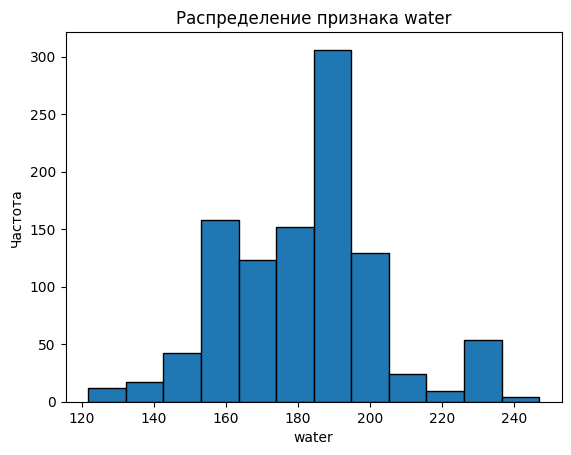

In [297]:
print_stats(df, 'water', k)

Распределение имеет почти нулевую ассиметрию (наблюдается небольшая правосторонняя ассиметрия). Между медианой, средним и модой имеется небольшая разница.  
Распределение признака близко к нормальному, но не идеально нормальное из-за выбросов.

### Анализ параметра Superplasticizer (Количество суперпластификатора)

Статистика для признака superplasticizer:
--------------------------|-------------------------------------------
Среднее:                  | 6.204660194174758
Медиана:                  | 6.4
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 32.2
Размах:                   | 32.2
Стандартное отклонение:   | 5.97384139248552
Дисперсия:                | 35.68678098257333
Асимметрия:               | 0.9072025748672465
Эксцесс:                  | 1.4112689653489738
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 6.4, 0.75: 10.2}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=9.065e-29 → Далеко от нормального
Д'Агостино-Пиросона:      | p=3.459e-31 → Далеко от нормального
Колмагорова-Смирнова      | p=1.199e-43 → Далеко от нормального



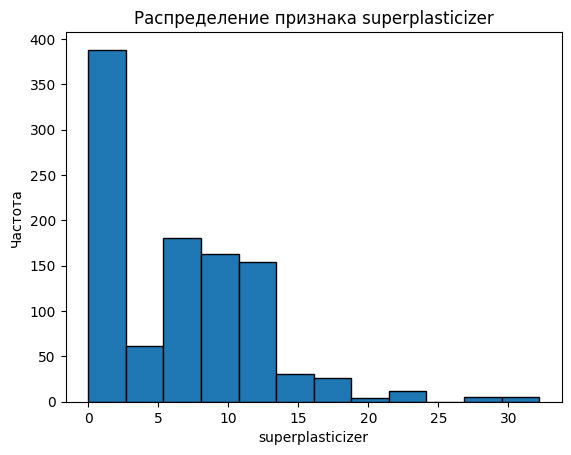

In [298]:
print_stats(df, 'superplasticizer', k)

Расперделение является островершинным и имеет правосторонную ассиметрию. Между медианой, средним и иодой имеется разница.  
На основе результатов тестов и анализа распределение не явялется нормальным.

### Анализ параметра Coarse Aggregate (Количество крупного заполнителя)

Статистика для признака coarse_aggregate:
--------------------------|-------------------------------------------
Среднее:                  | 972.9189320388349
Медиана:                  | 968.0
Мода:                     | 932.0
Минимум:                  | 801.0
Максимум:                 | 1145.0
Размах:                   | 344.0
Стандартное отклонение:   | 77.75395396672077
Дисперсия:                | 6045.677357458932
Асимметрия:               | -0.04021974481106706
Эксцесс:                  | -0.5990161032185637
Квантили (25%, 50%, 75%): | {0.25: 932.0, 0.5: 968.0, 0.75: 1029.4}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=8.347e-10 → Далеко от нормального
Д'Агостино-Пиросона:      | p=8.455e-08 → Далеко от нормального
Колмагорова-Смирнова      | p=4.311e-04 → Далеко от нормального



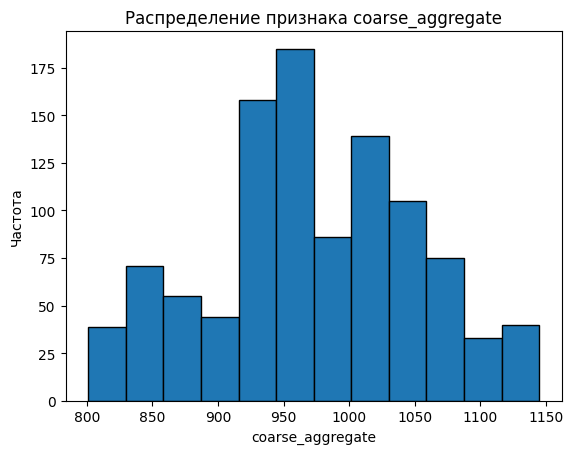

In [299]:
print_stats(df, 'coarse_aggregate', k)

Распределение имеет незначительую асимметрию, значения среднего, моды и медианы достаточно близки, но распределение является плосковершинным.  
Распределение близко к нормальному, но из-за значения эксцесса его таким назвать нельзя.

### Анализ параметра Fine Aggregate (Количество мелкого заполнителя)

Статистика для признака fine_aggregate :
--------------------------|-------------------------------------------
Среднее:                  | 773.5804854368932
Медиана:                  | 779.5
Мода:                     | 594.0
Минимум:                  | 594.0
Максимум:                 | 992.6
Размах:                   | 398.6
Стандартное отклонение:   | 80.17598014240437
Дисперсия:                | 6428.18779179522
Асимметрия:               | -0.25300959769707576
Эксцесс:                  | -0.10217698932117791
Квантили (25%, 50%, 75%): | {0.25: 730.95, 0.5: 779.5, 0.75: 824.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.842e-10 → Далеко от нормального
Д'Агостино-Пиросона:      | p=3.714e-03 → Далеко от нормального
Колмагорова-Смирнова      | p=4.938e-07 → Далеко от нормального



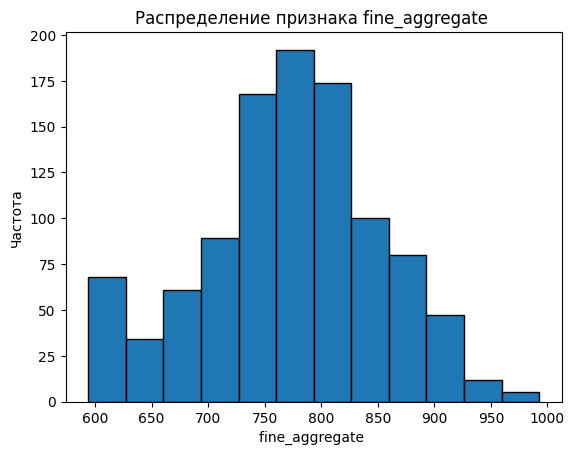

In [300]:
print_stats(df, 'fine_aggregate ', k)

### Анализ параметра Age (Возраст бетона на момент испытания)

Статистика для признака age:
--------------------------|-------------------------------------------
Среднее:                  | 45.662135922330094
Медиана:                  | 28.0
Мода:                     | 28
Минимум:                  | 1
Максимум:                 | 365
Размах:                   | 364
Стандартное отклонение:   | 63.16991158103249
Дисперсия:                | 3990.437729155462
Асимметрия:               | 3.26917740063459
Эксцесс:                  | 12.168988978672088
Квантили (25%, 50%, 75%): | {0.25: 7.0, 0.5: 28.0, 0.75: 56.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=7.718e-44 → Далеко от нормального
Д'Агостино-Пиросона:      | p=1.071e-158 → Далеко от нормального
Колмагорова-Смирнова      | p=5.019e-105 → Далеко от нормального



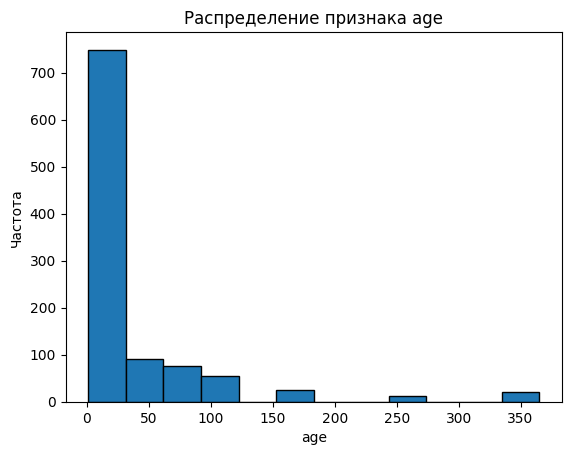

In [301]:
print_stats(df, 'age', k)

### Анализ параметра Concrete compressive strength (Прочность бетона на сжатие)

Статистика для признака concrete_compressive_strength:
--------------------------|-------------------------------------------
Среднее:                  | 35.817961165048544
Медиана:                  | 34.445
Мода:                     | 33.4
Минимум:                  | 2.33
Максимум:                 | 82.6
Размах:                   | 80.27
Стандартное отклонение:   | 16.705741961912512
Дисперсия:                | 279.08181449800446
Асимметрия:               | 0.416977288410718
Эксцесс:                  | -0.3137248604469969
Квантили (25%, 50%, 75%): | {0.25: 23.71, 0.5: 34.445, 0.75: 46.135000000000005}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=9.010e-11 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.937e-08 → Далеко от нормального
Колмагорова-Смирнова      | p=5.815e-02 → Нормальное



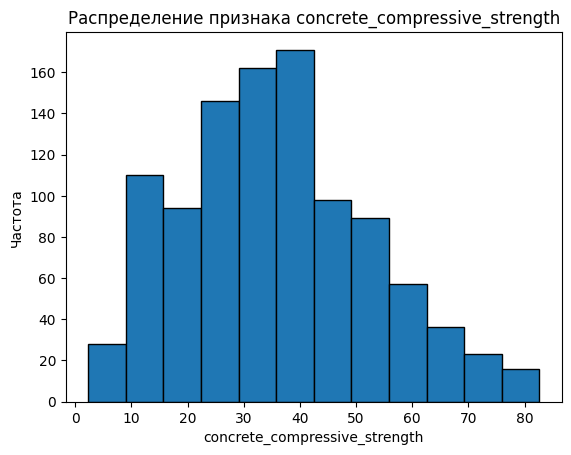

In [302]:
print_stats(df, 'concrete_compressive_strength', k)

# Подготовка данных
В датасете отсутвуют категориальные переменные. Так же в нем отсутвуют пустые значения:

In [303]:
print(f"Количество пропущенных значений: {df.isnull().sum().sum()}")

Количество пропущенных значений: 0


## Разделение выборки на train/test и стандартизация

In [304]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop(columns=['concrete_compressive_strength'])
y = df['concrete_compressive_strength']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=666
)

# Стандартизация признаков
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Ход работы
## Построение матрицы корреляции

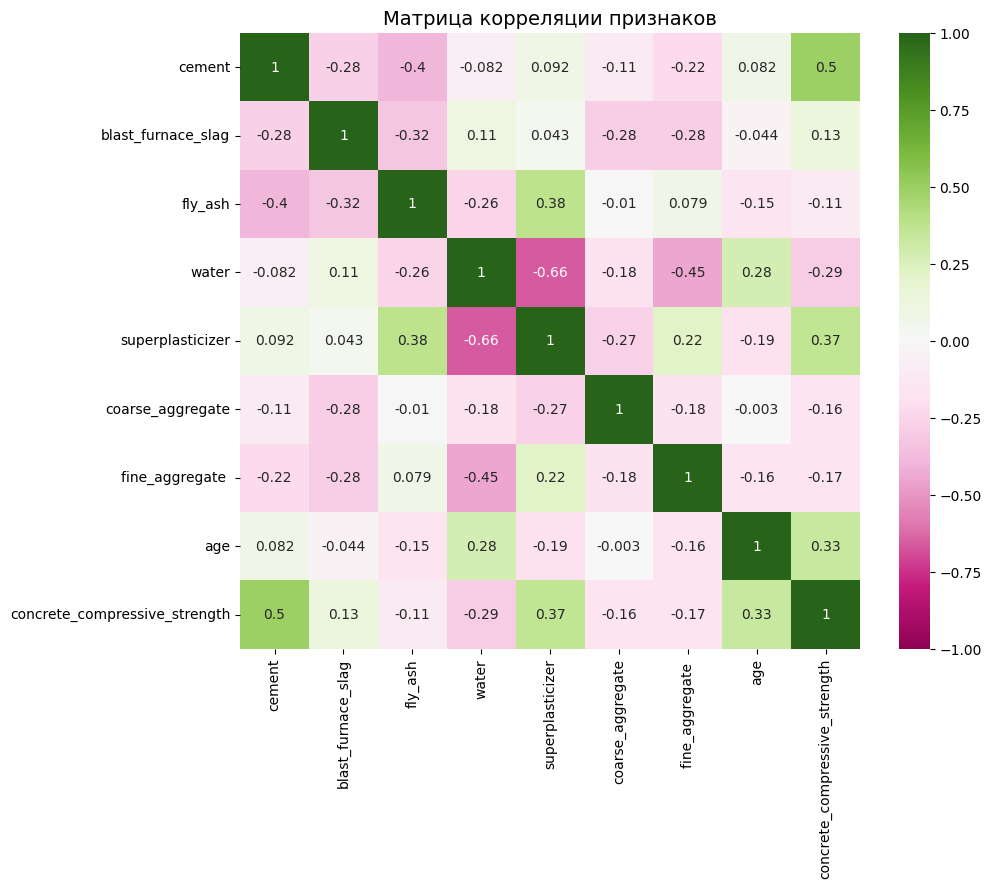

In [305]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков", fontsize=14)
plt.show()

Наблюдаем умереренную зависимость переменной concrete_compressive_strength с переменными cement, superplasticizer, age.

## Расчёт и анализ VIF-коэффициента
VIF — фактор инфляции дисперсии.
Он показывает, во сколько раз увеличивается дисперсия коэффициента регрессии из-за мультиколлинеарности между признаками.

Для расчёта используется следующие формулы:


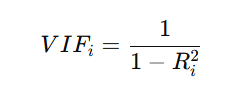

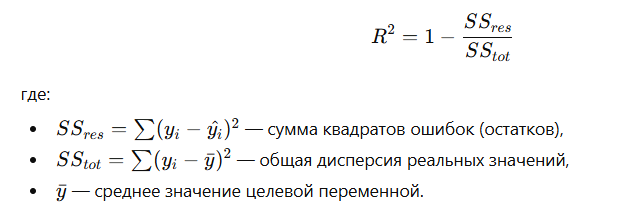


Наблюдается очень сильная мультиколлинеарность с параметрами water, coarse_aggregate и fine_aggregate, а также сильная мультиколлинеарность с параметром cement. 

In [306]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop('concrete_compressive_strength', axis=1)

vif_data = pd.DataFrame()
vif_data['Признак'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print('VIF коэффициенты для признаков:')
display(vif_data)

VIF коэффициенты для признаков:


,Признак,VIF
0,cement,15.456717
1,blast_furnace_slag,3.329127
2,fly_ash,4.147833
3,water,82.157569
4,superplasticizer,5.471094
5,coarse_aggregate,84.955779
6,fine_aggregate,72.790995
7,age,1.699459


## Расчёт метрик

Ниже приведена функция для расчёта метрик и кросс-валидации.

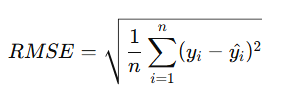

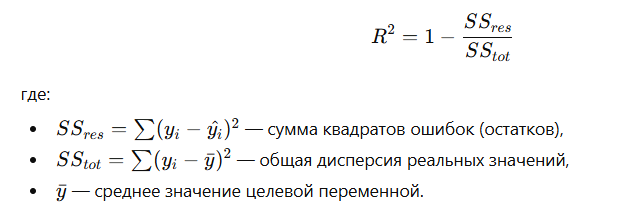

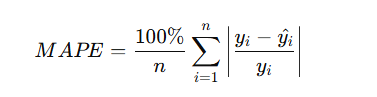
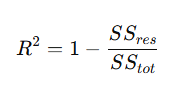

In [307]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import KFold, cross_val_predict


def evaluate_model(model, x_train, y_train, x_test, y_test, name):
    """Оценивает модель на тесте и кросс-валидации, возвращает DataFrame с метриками."""
    
    # --- Обучение и предсказание ---
    model.fit(x_train, y_train)
    y_pred_test = model.predict(x_test)
    
    # --- Метрики на тесте ---
    rmse_test = root_mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
    
    # --- Кросс-валидация ---
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(model, x_train, y_train, cv=kf)
    
    rmse_cv = root_mean_squared_error(y_train, y_pred_cv)
    r2_cv = r2_score(y_train, y_pred_cv)
    mape_cv = mean_absolute_percentage_error(y_train, y_pred_cv)
    
    # --- Результаты в DataFrame ---
    results = pd.DataFrame({
        "Метрика": ["RMSE", "R²", "MAPE"],
        name: [rmse_test, r2_test, mape_test],
        f"{name} (кросс-валидация)": [rmse_cv, r2_cv, mape_cv]
    })
    
    return results.round(3)

## Линейная регрессия до устранения мультиколлинеарности

In [308]:
lin_red_results = evaluate_model(LinearRegression(), x_train, y_train, x_test, y_test, "Линейная регрессия")
display(lin_red_results)

,Метрика,Линейная регрессия,Линейная регрессия (кросс-валидация)
0,RMSE,8.583,10.967
1,R²,0.691,0.582
2,MAPE,0.276,0.329


## Гребневая регрессия до устранения мультиколлинеарности

In [309]:
ridge_results = evaluate_model(Ridge(alpha=1), x_train, y_train, x_test, y_test, "Гребневая регрессия")
display(ridge_results)


,Метрика,Гребневая регрессия,Гребневая регрессия (кросс-валидация)
0,RMSE,8.593,10.967
1,R²,0.690,0.582
2,MAPE,0.277,0.329


## Метод PCA

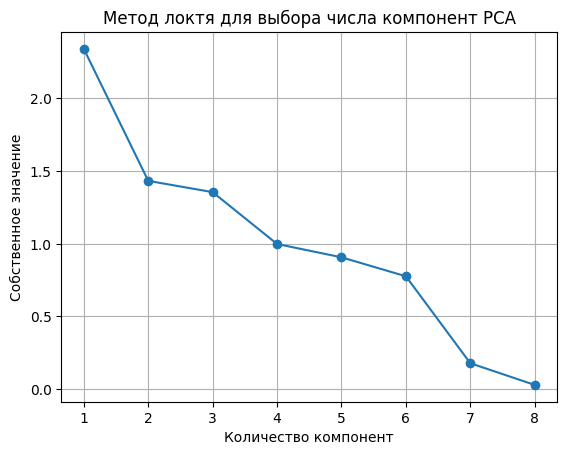

Выбрано компонент: 6


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
PC1,0.077,0.196,-0.379,0.547,-0.498,0.030,-0.420,0.296
PC2,-0.190,-0.576,0.270,0.039,-0.359,0.648,0.035,0.087
PC3,0.788,-0.422,-0.358,-0.184,0.073,0.030,0.066,0.169
PC4,-0.059,-0.329,0.371,0.307,0.053,-0.541,0.199,0.567
PC5,-0.234,0.004,-0.477,0.007,-0.341,-0.091,0.769,-0.039
PC6,-0.190,0.303,-0.154,-0.365,0.239,0.332,0.031,0.739


In [310]:
from sklearn.decomposition import PCA

# --- PCA и метод локтя ---
pca = PCA().fit(x_train)
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o')
plt.xlabel('Количество компонент')
plt.ylabel('Собственное значение')
plt.title('Метод локтя для выбора числа компонент PCA')
plt.grid(True)
plt.show()

# --- Выбор числа компонент (≥95% объяснённой дисперсии) ---
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Выбрано компонент: {n_components}")

# --- Преобразование данных ---
pca = PCA(n_components=n_components)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# --- Посмотрим, какие признаки формируют каждую компоненту ---
pca_components = pd.DataFrame(
    pca.components_,                
    columns=df.drop(columns=['concrete_compressive_strength']).columns,        
    index=[f'PC{i+1}' for i in range(pca.n_components_)]  
)

display(pca_components.round(3))


## Линейная регрессия после устранения мультиколлинеарности

In [311]:
lin_red_results_pca = evaluate_model(LinearRegression(), x_train_pca, y_train, x_test_pca, y_test, "Линейная регрессия после PCA")
display(lin_red_results_pca)

,Метрика,Линейная регрессия после PCA,Линейная регрессия после PCA (кросс-валидация)
0,RMSE,9.743,11.499
1,R²,0.602,0.540
2,MAPE,0.328,0.348


## Гребневая регрессия после устранения мультиколлинеарности

In [312]:
ridge_results_pca = evaluate_model(Ridge(alpha=1), x_train_pca, y_train, x_test_pca, y_test, "Гребневая регрессия после PCA")
display(ridge_results_pca)

,Метрика,Гребневая регрессия после PCA,Гребневая регрессия после PCA (кросс-валидация)
0,RMSE,9.742,11.498
1,R²,0.602,0.540
2,MAPE,0.329,0.348


## Проверка устранения мультикалинеарности

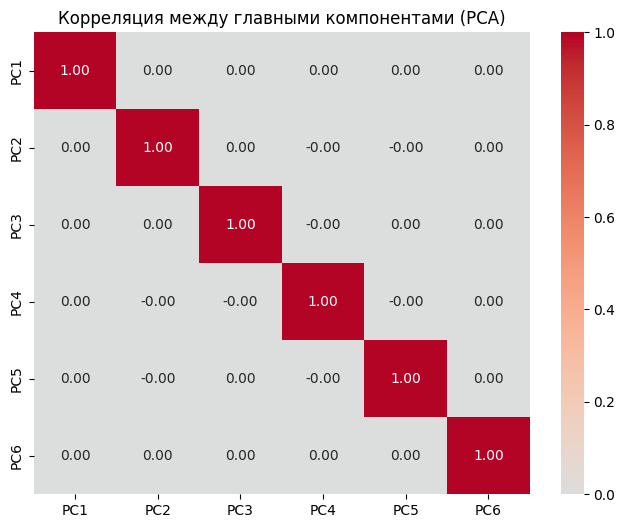

In [319]:
# Преобразуем x_train_pca в DataFrame для наглядности
pca_df = pd.DataFrame(
    x_train_pca,
    columns=[f'PC{i+1}' for i in range(x_train_pca.shape[1])]
)

corr_matrix = pca_df.corr()

plt.figure(figsize=(8,6))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Корреляция между главными компонентами (PCA)")
plt.show()

## Выводы

In [320]:
results_total = lin_red_results.merge(ridge_results, on="Метрика")
results_total_pca = lin_red_results_pca.merge(ridge_results_pca, on="Метрика")
display(results_total)
display(results_total_pca)

,Метрика,Линейная регрессия,Линейная регрессия (кросс-валидация),Гребневая регрессия,Гребневая регрессия (кросс-валидация)
0,RMSE,8.583,10.967,8.593,10.967
1,R²,0.691,0.582,0.690,0.582
2,MAPE,0.276,0.329,0.277,0.329


,Метрика,Линейная регрессия после PCA,Линейная регрессия после PCA (кросс-валидация),Гребневая регрессия после PCA,Гребневая регрессия после PCA (кросс-валидация)
0,RMSE,9.743,11.499,9.742,11.498
1,R²,0.602,0.540,0.602,0.540
2,MAPE,0.328,0.348,0.329,0.348


1. Линейная регрессия
    - RMSE = 8.583 → средняя ошибка прогноза около 8.6 единиц.
    - R² = 0.691 → модель объясняет ~69% дисперсии целевой переменной.
    - MAPE = 0.276 → средняя процентная ошибка около 27,6%.
    - Вывод: линейная регрессия показывает среднюю точность, работает неплохо, но не идеально. Кросс-валидация показывает более высокие ошибки (RMSE = 10.967), значит есть некоторая нестабильность модели на разных выборках.
2. Гребневая регрессия
    - Показывает аналогичные значения метрик, но более устойчива к коллинеарности и выбросам.
3. После применения PCA
    - Качество линейной модели стало хуже, но она стала более устойчивой
    - Гребневая не поменялась, тк изначально включает в себя устранение мультиколлинеарности